# Modelo VAE

im a coping this notebook https://github.com/evasnow1992/DeepGenerativeModelLINCS/blob/master/deep_generative_model_LINCS.ipynb


A **Variational Autoencoder (VAE)** is a generative model that learns to encode input data into a low-dimensional **latent space** and then decode it back to reconstruct the original input. Unlike traditional autoencoders, VAEs learn a **probabilistic latent space** by mapping inputs to a distribution (mean and variance), allowing them to generate new, realistic samples by sampling from that space.


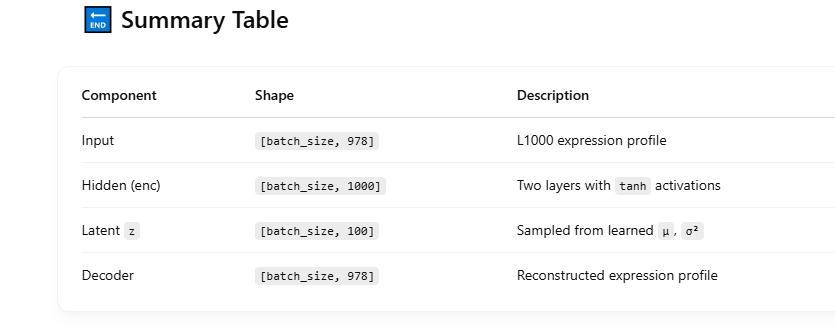

In this context, the VAE is used to **compress high-dimensional gene expression profiles (978 landmark genes)** into a **low-dimensional latent space (100 features)** that captures the essential biological variation. This latent space can then be used for tasks like:

- 🧬 **Drug effect representation**  
- 🔍 **Clustering or comparing perturbagens**
- 📉 **Dimensionality reduction** before classification
- 🤖 **Input to downstream ML models**

**What is the decoder used for?**

The encoder is the main tool used to extract compact representations (100-dim vectors) of the gene expression profiles.

The decoder is used only during training to ensure the latent representation preserves enough information to reconstruct the original 978-gene input.

The goal is not to use the decoder later, but to train a powerful encoder.


So, the VAE learns a compact, meaningful representation of gene expression changes caused by different compounds or genetic perturbations.

In [ ]:
!pip install cmapPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## 1) Loading trained model

In [ ]:
import pandas as pd
import gzip, shutil
import os
import pkg_resources

from cmapPy.pandasGEXpress.parse import parse
import torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torch import nn
from torch.autograd import Variable

In [ ]:
# Load model components
encoder = torch.load('/content/drive/MyDrive/CMAPS_VAE/VAE_encode_sfb.pth', weights_only=False)
mu_layer = torch.load('/content/drive/MyDrive/CMAPS_VAE/VAE_mu_sfb.pth', weights_only=False)
logvar_layer = torch.load('/content/drive/MyDrive/CMAPS_VAE/VAE_logvar_sfb.pth', weights_only=False)
input_data = pd.read_csv('/content/drive/MyDrive/CMAPS_VAE/drug_signatures_drugcomb_cmaps_combination.csv')




In [ ]:
input_data = input_data.drop(columns=['rid'])
print(input_data.shape)
input_data

(978, 126)


,fluorouracil_A375,fluorouracil_HT29,fluorouracil_MCF7,veliparib_A375,veliparib_HT29,MK-1775_A375,MK-1775_HT29,NVP-BEZ235_A375,NVP-BEZ235_HT29,bortezomib_A375,...,ruxolitinib_HT29,ruxolitinib_MCF7,crizotinib_A549,crizotinib_HT29,crizotinib_MCF7,vismodegib_HT29,vismodegib_MCF7,vandetanib_A549,vandetanib_HT29,vandetanib_MCF7
0,-0.454034,0.556375,-0.241931,0.232655,0.132375,0.933442,-0.286527,0.571513,2.081833,4.519782,...,-0.189953,0.142635,0.132573,0.378890,0.788946,0.121903,-0.387006,0.389896,0.065462,1.088273
1,-0.061263,-0.303017,-0.070943,-0.063150,0.073779,1.349271,-0.168490,1.029521,1.175860,4.240863,...,-0.476028,-0.356934,-0.133523,0.445198,0.191256,-0.795835,-0.416783,0.167681,0.123265,0.168304
2,0.458396,-0.112558,-0.521271,-0.130233,0.240076,-0.559515,-0.691441,0.927662,-1.006166,-2.338197,...,0.106898,0.412513,-0.578974,-0.589351,-0.290396,-0.479794,-0.652074,-0.698794,-0.057060,-0.178580
3,-0.013901,-0.116283,-0.102935,0.343411,0.004642,1.558415,0.744736,-0.759341,-0.152758,5.891055,...,0.699038,0.009236,0.040954,-0.033205,0.439969,0.439828,0.166281,0.440294,0.048169,0.079787
4,0.224778,-0.288575,-0.312377,-0.168420,-0.464064,-0.131803,0.339135,1.264653,1.243738,4.625013,...,-0.184445,-0.047064,-0.572966,0.740158,0.644811,-0.560352,0.042487,0.323582,-0.176176,0.396500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,-0.046469,0.228017,0.113124,0.133784,0.095374,0.062771,-0.317576,-0.048354,0.401185,4.034200,...,-0.396192,-0.097672,-0.094230,-0.032198,-0.083014,0.073672,-0.075906,0.203334,0.228294,0.555357
974,0.196210,0.625300,-0.216124,0.305656,0.241276,-0.153740,0.368022,-0.786243,-0.051111,-0.138223,...,0.289809,0.601744,-0.075359,-0.127368,0.217210,0.493079,0.677853,0.333448,0.201346,-0.292288
975,0.731427,0.379617,0.383257,0.105282,-0.039592,0.137195,-0.697365,0.905309,1.814131,-4.738132,...,-0.343929,0.556174,-0.219226,1.374665,0.621156,-0.426729,0.118265,0.778324,0.784130,0.217076
976,0.184210,3.473634,1.900386,0.008532,0.643490,1.037282,-0.527081,1.504527,1.846780,-3.324922,...,0.143491,0.160987,-0.247379,1.154861,0.334035,0.328938,0.228816,0.297642,0.123095,-0.589260


In [ ]:
encoder.eval()
mu_layer.eval()
logvar_layer.eval()

if torch.cuda.is_available():
    encoder = encoder.cuda()
    mu_layer = mu_layer.cuda()
    logvar_layer = logvar_layer.cuda()

**Step 2:** Prepare Your Input Data
Make sure your input is:

A tensor of shape [batch_size, 978]

Of type torch.FloatTensor

Normalized the same way as during training (if applicable)

In [ ]:
import torch
import numpy as np
import pandas as pd

# 1. Transpose and convert to tensor
X = input_data.T.values.astype(np.float32)  # shape: (126, 978)
X_tensor = torch.tensor(X)

if torch.cuda.is_available():
    X_tensor = X_tensor.cuda()

 **Step 3:** Encode and Get μ, σ² and z

In [ ]:
with torch.no_grad():
    h1 = encoder[1](encoder[0](X_tensor))
    h = encoder[3](encoder[2](h1))

    mu = mu_layer(h)
    logvar = logvar_layer(h)

    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)  # Random noise
    z = mu + std * eps  # Reparameterization trick


In [ ]:
z.shape

torch.Size([126, 5])

In [ ]:
mu.shape

torch.Size([126, 5])

im using mu as  for the embeddings as it represents the latent space mean

In [ ]:
import pandas as pd

# Get sample names before converting to .values
sample_names = input_data.columns


In [ ]:
# Move mu to CPU and convert to numpy
mu_np = mu.cpu().numpy()

# Create DataFrame: now each column will be a sample
mu_df = pd.DataFrame(mu_np.T, columns=sample_names)

# Name the rows (latent dimensions)
mu_df.index = [f'latent_{i}' for i in range(mu_df.shape[0])]

In [ ]:
mu_df

,fluorouracil_A375,fluorouracil_HT29,fluorouracil_MCF7,veliparib_A375,veliparib_HT29,MK-1775_A375,MK-1775_HT29,NVP-BEZ235_A375,NVP-BEZ235_HT29,bortezomib_A375,...,ruxolitinib_HT29,ruxolitinib_MCF7,crizotinib_A549,crizotinib_HT29,crizotinib_MCF7,vismodegib_HT29,vismodegib_MCF7,vandetanib_A549,vandetanib_HT29,vandetanib_MCF7
latent_0,0.038970,0.038676,-0.016287,0.091878,0.074371,-0.019640,0.042824,-0.062805,-0.032479,-0.753018,...,-0.097786,0.025045,0.020186,-0.012530,0.015081,-0.000928,-0.005586,-0.019738,0.026374,-0.065987
latent_1,0.091919,0.060642,0.094303,0.035634,0.009254,0.171703,0.073104,-0.013919,-0.047039,0.077787,...,0.077715,0.098051,0.155192,0.118200,0.167498,0.070335,0.052117,0.039012,0.114248,0.087140
latent_2,-0.356127,-0.250747,-0.190999,-0.397167,-0.436691,0.233959,-0.321235,0.019822,0.105879,2.799098,...,-0.107125,-0.316435,-0.110395,0.030044,-0.040945,-0.216805,-0.247867,-0.195481,-0.335605,-0.112513
latent_3,0.083798,0.069042,0.136447,0.071651,0.078889,0.032443,0.094398,0.143761,0.177744,-1.703755,...,0.110171,0.055549,0.154559,0.098975,0.138726,0.120469,0.071396,0.091305,0.100343,0.114887
latent_4,-0.105576,-0.053469,-0.083395,-0.086720,-0.106691,-0.213519,-0.081323,-0.064544,0.024956,-0.008714,...,0.056914,-0.085231,-0.031856,0.006966,-0.011450,0.015979,-0.031808,-0.045924,-0.131644,0.061215


In [ ]:
# Save to CSV
mu_df.to_csv('/content/drive/MyDrive/CMAPS_VAE/mu_embeddings_transposed.csv')

## 2) Make model that embbeds into 5 dimensions

In [ ]:
import pandas as pd
import gzip, shutil
import os
import pkg_resources

from cmapPy.pandasGEXpress.parse import parse
import torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive/CMAPS_VAE')


['GSE70138_Broad_LINCS_pert_info.txt.gz',
 'GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz',
 'GSE70138_Broad_LINCS_cell_info_2017-04-28.txt.gz',
 'GSE70138_Broad_LINCS_inst_info_2017-03-06.txt.gz',
 'GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz',
 'GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt.gz',
 'GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx',
 'VAE_encode_GP.pth',
 'VAE_encode_SMGP.pth',
 'VAE_encode_SMP.pth',
 'VAE_logvar_GP.pth',
 'VAE_logvar_SMGP.pth',
 'VAE_logvar_SMP.pth',
 'VAE_mu_GP.pth',
 'VAE_mu_SMGP.pth',
 'VAE_mu_SMP.pth',
 'drug_signatures_drugcomb_cmaps_combination.csv',
 'VAE_encode.pth',
 'VAE_mu.pth',
 'VAE_logvar.pth',
 'VAE_decode.pth',
 'VAE_encode_sfb.pth',
 'VAE_mu_sfb.pth',
 'VAE_logvar_sfb.pth',
 'VAE_decode_sfb.pth',
 'mu_embeddings_transposed.csv',
 'final_df.csv',
 'Untitled',
 'dataset_encoded.csv',
 'categorical_variables_mapping.csv',
 'numerical_variables_mapping.csv',
 'numerical_variables_mapping_normalized.csv']

In [ ]:
# gene info
file_path = r"/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz"
with gzip.open(file_path, 'rt') as f:
    gene_info = pd.read_csv(f, sep='\t')

# cell info
file_path = r"/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_cell_info_2017-04-28.txt.gz"
with gzip.open(file_path, 'rt') as f:
    cell_info = pd.read_csv(f, sep='\t')

# pert info
file_path = r"/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_pert_info.txt.gz"
with gzip.open(file_path, 'rt') as f:
    pert_info = pd.read_csv(f, sep='\t')

# inst info
file_path = r"/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_inst_info_2017-03-06.txt.gz"
with gzip.open(file_path, 'rt') as f:
    inst_info = pd.read_csv(f, sep='\t')

# sig info
file_path = r"/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz"
with gzip.open(file_path, 'rt') as f:
    sig_info = pd.read_csv(f, sep='\t')

# sig metrics
file_path = r"/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt.gz"
with gzip.open(file_path, 'rt') as f:
    sig_metrics = pd.read_csv(f, sep='\t')

**Load signature metadata**

In [ ]:
cellLineNameSM = set(["A375", "HA1E", "HELA", "HT29", "MCF7", "PC3", "YAPC"])
cellLineNameGP = set(["A375", "A549", "HA1E", "HCC515", "HEPG2", "HT29", "MCF7", "PC3", "VCAP"])

In [ ]:
sigInfoSM = sig_info
cellLineInfoSM = sigInfoSM[sigInfoSM["cell_id"].isin(cellLineNameSM)]
cellLineSigSM = cellLineInfoSM["sig_id"]
cellLinePertSM = cellLineInfoSM["pert_id"]
cellLinePertTypeSM = cellLineInfoSM["pert_type"]
print(sigInfoSM.shape)
print(cellLineInfoSM.shape)

(118050, 8)
(85183, 8)


In [ ]:
pertDicSM = {}
pertArraySM = cellLinePertSM.values
for i in range(len(pertArraySM)):
    pertSM = pertArraySM[i]
    c = pertDicSM.setdefault(pertSM, 0)
    pertDicSM[pertSM] = c + 1
print("The number of perturbagens: " + str(len(pertDicSM)))

The number of perturbagens: 1797


**Load gene information**

In [ ]:
geneInfoSM = gene_info
lmInfoSM = geneInfoSM["pr_gene_id"][geneInfoSM["pr_is_lm"] == 1].astype(str) # landmark genes only
print(geneInfoSM.shape)
print(lmInfoSM.shape)

(12328, 5)
(978,)


**Load and process all L1000 data**

In [ ]:
##tarda un poquito
L1000FileNameSM = "/content/drive/MyDrive/CMAPS_VAE/GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx"
gctoo_cellLineSM = parse(L1000FileNameSM, cid = cellLineSigSM, rid = lmInfoSM)
print(gctoo_cellLineSM.data_df.shape)
print(max(gctoo_cellLineSM.data_df.max()))
print(min(gctoo_cellLineSM.data_df.min()))

/usr/local/lib/python3.11/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.11/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


(978, 85183)
10.000001907348633
-10.000001907348633


In [ ]:
from __future__ import division
import sys
import math
import time
import operator
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cmapPy as cp
from cmapPy.pandasGEXpress.parse import parse
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils import data as Tdata
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

In [ ]:
expDataSM = torch.Tensor(gctoo_cellLineSM.data_df.transpose().values.astype(np.float32))
expDatasetSM = Tdata.TensorDataset(expDataSM)

**Load signature metadata**

In [ ]:
sigInfoGP = sig_info
cellLineInfoGP = sigInfoGP[sigInfoGP["cell_id"].isin(cellLineNameGP)]
cellLineSigGP = cellLineInfoGP["sig_id"]
cellLinePertGP = cellLineInfoGP["pert_iname"]
cellLinePertTypeGP = cellLineInfoGP["pert_type"]
print(sigInfoGP.shape)
print(cellLineInfoGP.shape)

(118050, 8)
(69826, 8)


In [ ]:
pertDicGP = {}
pertArrayGP = cellLinePertGP.values
for i in range(len(pertArrayGP)):
    pertGP = pertArrayGP[i]
    c = pertDicGP.setdefault(pertGP, 0)
    pertDicGP[pertGP] = c + 1
print("The number of perturbagens: " + str(len(pertDicGP)))

The number of perturbagens: 1769


In [ ]:
print(gctoo_cellLineSM.data_df.index.values[0:8])
print(gctoo_cellLineSM.data_df.index.values[-8:])

['780' '7849' '6193' '23' '9552' '387' '10921' '10285']
['6915' '6253' '7264' '5467' '2767' '23038' '57048' '79716']


**Variational AutoEncoder**


In [ ]:
class VAE(nn.Module):
    def __init__(self, hiddenSize = 100):
        super(VAE, self).__init__()
        self.hiddenSize = hiddenSize
        self.encoder = nn.Sequential(
            nn.Linear(978, 1000),
            nn.Tanh(),
            nn.Linear(1000, 1000),
            nn.Tanh())
        self.decoder = nn.Sequential(
            nn.Linear(self.hiddenSize, 1000),
            nn.Tanh(),
            nn.Linear(1000, 1000),
            nn.Tanh(),
            nn.Linear(1000, 978),
            nn.Tanh())
        self.mu = torch.nn.Linear(1000, self.hiddenSize)
        self.logvar = torch.nn.Linear(1000, self.hiddenSize)

    def reparametrize(self, h):
        mu = self.mu(h)
        logvar = self.logvar(h)
        std = logvar.mul(0.5).exp_()
        if torch.cuda.is_available():
            eps = torch.cuda.FloatTensor(std.size()).normal_()
        else:
            eps = torch.FloatTensor(std.size()).normal_()
        eps = Variable(eps)
        return eps.mul(std).add_(mu), mu, logvar

    def forward(self, x):
        h1 = self.encoder[1](self.encoder[0](x))
        h = self.encoder[3](self.encoder[2](h1))
        z, mu, logvar = self.reparametrize(h)
        decoded = self.decoder(z)
        return decoded * 10, mu, logvar, z, h1

    def generate_sample(self):
        z = torch.FloatTensor(self.hiddenSize).normal_()
        return self.decoder(z)

In [ ]:
reconstruction_function = nn.MSELoss()
def loss_function(recon_x, x, mu, logvar):
    """
    mu: latent mean
    logvar: latent log variance
    """
    BCE = reconstruction_function(recon_x, x)  # mse loss
    KLD_element = mu.pow(2).add_(logvar.exp()).mul_(-1).add_(1).add_(logvar) # KL(q(z|x)||p(z))
    KLD = torch.mean(KLD_element).mul_(-0.5)
    return BCE + KLD

**Start training**

In [ ]:
num_epochs = 300
learning_rate = 1e-3
batch_size = 512
model_VAE = VAE(hiddenSize = 5)
if torch.cuda.is_available():
    model_VAE.cuda()
optimizer = torch.optim.Adam(model_VAE.parameters(), lr = learning_rate)

In [ ]:
useData = 'SM'
if useData == 'SM':
    expTrainDatasetSM, expValidDatasetSM = Tdata.random_split(expDatasetSM, [expDataSM.size()[0] - expDataSM.size()[0]//10, expDataSM.size()[0]//10])
    expTrainLoader = Tdata.DataLoader(dataset = expTrainDatasetSM, batch_size = batch_size, shuffle = True)
    expValidLoader = Tdata.DataLoader(dataset = expValidDatasetSM)
    print(len(expTrainLoader.dataset), len(expValidLoader.dataset))
elif useData == 'GP':
    expTrainDatasetGP, expValidDatasetGP = Tdata.random_split(expDatasetGP, [expDataGP.size()[0] - expDataGP.size()[0]//10, expDataGP.size()[0]//10])
    expTrainLoader = Tdata.DataLoader(dataset = expTrainDatasetGP, batch_size = batch_size, shuffle = True)
    expValidLoader = Tdata.DataLoader(dataset = expValidDatasetGP)
    print(len(expTrainLoader.dataset), len(expValidLoader.dataset))
elif useData == 'both':
    expTrainDatasetBoth, expValidDatasetBoth = Tdata.random_split(expDatasetBoth, [expDataBoth.size()[0] - expDataBoth.size()[0]//10, expDataBoth.size()[0]//10])
    expTrainLoader = Tdata.DataLoader(dataset = expTrainDatasetBoth, batch_size = batch_size, shuffle = True)
    expValidLoader = Tdata.DataLoader(dataset = expValidDatasetBoth)
    print(len(expTrainLoader.dataset), len(expValidLoader.dataset))
else:
    print("Error! Unidentified type of useData!")

76665 8518


In [ ]:
epoch_train_loss = []
startTime = time.time()
for epoch in range(num_epochs):
    model_VAE.train()
    lossList = []
    for step, data in enumerate(expTrainLoader):
        optimizer.zero_grad()
        inputData = data[0]
        if torch.cuda.is_available():
            inputData = inputData.cuda()
        recon_batch, mu, logvar, encoded, h1 = model_VAE(inputData)
        loss = loss_function(recon_batch, inputData, mu, logvar)
        loss.backward()
        optimizer.step()
        lossList.append(reconstruction_function(recon_batch, inputData).detach().cpu().numpy())
        #lossList.append(reconstruction_function(recon_batch, inputData).data.numpy())
    epochLoss = np.mean(lossList)
    epoch_train_loss.append(epochLoss)
    print('Epoch: ', epoch, '| train loss: %.4f' % epochLoss)
timeSpent = round(time.time() - startTime, 2)
print('Done.\nTime spent: ' + str(timeSpent) + 's.')

<ipython-input-23-2338798915>:25: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  eps = torch.cuda.FloatTensor(std.size()).normal_()


Epoch:  0 | train loss: 1.9056
Epoch:  1 | train loss: 1.6898
Epoch:  2 | train loss: 1.6367
Epoch:  3 | train loss: 1.6141
Epoch:  4 | train loss: 1.6039
Epoch:  5 | train loss: 1.5920
Epoch:  6 | train loss: 1.5827
Epoch:  7 | train loss: 1.5759
Epoch:  8 | train loss: 1.5665
Epoch:  9 | train loss: 1.5650
Epoch:  10 | train loss: 1.5622
Epoch:  11 | train loss: 1.5601
Epoch:  12 | train loss: 1.5586
Epoch:  13 | train loss: 1.5561
Epoch:  14 | train loss: 1.5518
Epoch:  15 | train loss: 1.5485
Epoch:  16 | train loss: 1.5476
Epoch:  17 | train loss: 1.5434
Epoch:  18 | train loss: 1.5415
Epoch:  19 | train loss: 1.5402
Epoch:  20 | train loss: 1.5384
Epoch:  21 | train loss: 1.5387
Epoch:  22 | train loss: 1.5351
Epoch:  23 | train loss: 1.5328
Epoch:  24 | train loss: 1.5303
Epoch:  25 | train loss: 1.5312
Epoch:  26 | train loss: 1.5312
Epoch:  27 | train loss: 1.5289
Epoch:  28 | train loss: 1.5290
Epoch:  29 | train loss: 1.5268
Epoch:  30 | train loss: 1.5264
Epoch:  31 | train

Text(0.5, 0, 'epoch')

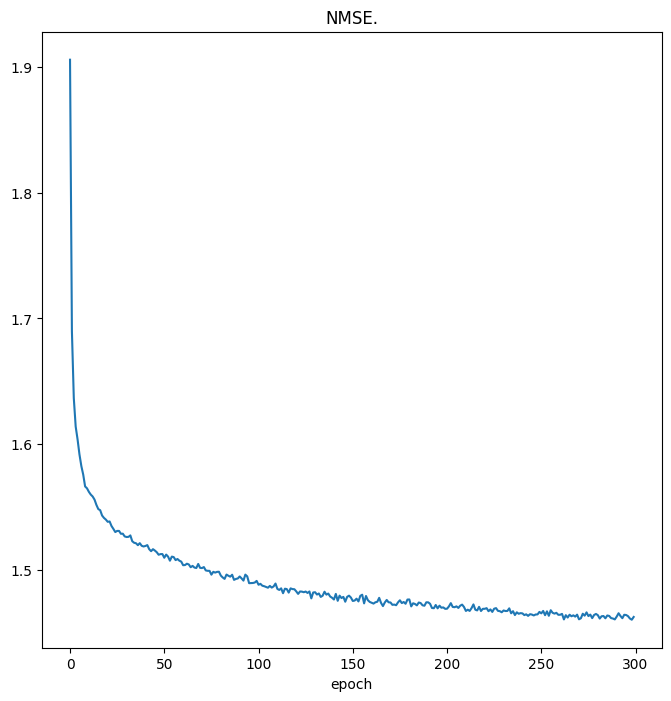

In [ ]:
f = plt.figure(figsize=(8,8))
ax = f.add_subplot(1,1,1)
ax.plot(epoch_train_loss)
ax.set_title('NMSE.')
ax.set_xlabel('epoch')

In [ ]:
torch.save(model_VAE.encoder, '/content/drive/MyDrive/CMAPS_VAE/VAE_encode_sfb.pth')
torch.save(model_VAE.mu, '/content/drive/MyDrive/CMAPS_VAE/VAE_mu_sfb.pth')
torch.save(model_VAE.logvar, '/content/drive/MyDrive/CMAPS_VAE/VAE_logvar_sfb.pth')
torch.save(model_VAE.decoder, '/content/drive/MyDrive/CMAPS_VAE/VAE_decode_sfb.pth')

**Validation on independent dataset**

In [ ]:
model_VAE.eval()
validLossList = []
for data in expValidLoader:
    inputData = data[0]
    if torch.cuda.is_available():
        inputData = inputData.cuda()
    recon_batch, mu, logvar, _, _ = model_VAE(inputData)
    loss = reconstruction_function(recon_batch, inputData)
    validLossList.append(loss.detach().cpu().numpy())
    #validLossList.append(loss.data.numpy())
print('Validation loss: %.4f' % np.mean(validLossList))

# ----- 🧪 Additional Metrics -----
import numpy as np
from sklearn.metrics import r2_score, explained_variance_score
from scipy.stats import pearsonr, spearmanr

# Stack all batches
original = np.vstack(all_original)
reconstructed = np.vstack(all_reconstructed)

# Flatten
original_flat = original.flatten()
reconstructed_flat = reconstructed.flatten()

# R² score
r2 = r2_score(original_flat, reconstructed_flat)
print(f"R² score: {r2:.4f}")

# Explained variance
evs = explained_variance_score(original_flat, reconstructed_flat)
print(f"Explained variance: {evs:.4f}")

# Pearson correlation
pearson_corr, _ = pearsonr(original_flat, reconstructed_flat)
print(f"Pearson correlation: {pearson_corr:.4f}")

# Spearman correlation
spearman_corr, _ = spearmanr(original_flat, reconstructed_flat)
print(f"Spearman correlation: {spearman_corr:.4f}")

Validation loss: 1.4979


NameError: name 'all_original' is not defined

In [ ]:
model_VAE.eval()
validLossList = []
all_original = []
all_reconstructed = []

for data in expValidLoader:
    inputData = data[0]
    if torch.cuda.is_available():
        inputData = inputData.cuda()
    recon_batch, mu, logvar, _, _ = model_VAE(inputData)

    loss = reconstruction_function(recon_batch, inputData)
    validLossList.append(loss.detach().cpu().numpy())

    # Guardar reconstruidos y originales para métricas
    all_original.append(inputData.detach().cpu().numpy())
    all_reconstructed.append(recon_batch.detach().cpu().numpy())

print('Validation loss: %.4f' % np.mean(validLossList))

# ----- 🧪 Additional Metrics -----
import numpy as np
from sklearn.metrics import r2_score, explained_variance_score
from scipy.stats import pearsonr, spearmanr

# Stack all batches
original = np.vstack(all_original)
reconstructed = np.vstack(all_reconstructed)

# Flatten
original_flat = original.flatten()
reconstructed_flat = reconstructed.flatten()

# R² score
r2 = r2_score(original_flat, reconstructed_flat)
print(f"R² score: {r2:.4f}")

# Explained variance
evs = explained_variance_score(original_flat, reconstructed_flat)
print(f"Explained variance: {evs:.4f}")

# Pearson correlation
pearson_corr, _ = pearsonr(original_flat, reconstructed_flat)
print(f"Pearson correlation: {pearson_corr:.4f}")

# Spearman correlation
spearman_corr, _ = spearmanr(original_flat, reconstructed_flat)
print(f"Spearman correlation: {spearman_corr:.4f}")


Validation loss: 1.5050
R² score: 0.3630
Explained variance: 0.3630
Pearson correlation: 0.6038
Spearman correlation: 0.2263
